# Unemployment Analysis with Python

## Objective
This project analyzes unemployment trends in India using Python. 

The analysis includes:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Covid-19 impact analysis
- Monthly unemployment trend analysis
- Visualization of unemployment patterns

Import Libraries 

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# optional libraries for advanced analysis and better representation
import plotly.express as px
sns.set_style('whitegrid')

# ignore unecessary warnings
import warnings
warnings.filterwarnings('ignore')

# if datasets is in different folder or directory other than current working structure, use this library to handle file paths
# from pathlib import Path 

Load datasets
Here we have two datasets, one for general unemployment and another for specific COVID-19 related unemployment. We will load both datasets and perform analysis on them.


In [50]:
df1 = pd.read_csv("../data/Unemployment_in_India.csv")
df2 = pd.read_csv("../data/Unemployment_Rate_upto_11_2020.csv")

# when the datasets are in different folder or directory other than current working structure, use this code to read the datasets using pathlib library
# data_dir = Path("data") if Path("data").exists() else Path("..") / "data"

Datasets preview

In [51]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [52]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


Datasets shape: It will tell about the rows and columns in the datasets.

In [53]:
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)


Datasets info

In [54]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [55]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [56]:
print(df1.columns)
print(df2.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [57]:
# Removing leading/trailing spaces from column names if any
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [58]:
print(df1.columns)
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [59]:
# conversion of date column to datetime format for better analysis
df1['Date'] = pd.to_datetime(df1['Date'], errors = 'coerce')
df2['Date'] = pd.to_datetime(df2['Date'], errors = 'coerce')

In [60]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 42.1 KB


In [61]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    str           
 1   Date                                     267 non-null    datetime64[us]
 2   Frequency                                267 non-null    str           
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    str           
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(3)
memo

In [62]:
# checking for missing values in both datasets
print("Dataset 1- Missing values:", df1.isnull().sum())
print("Dataset 2- Missing values:", df2.isnull().sum())

Dataset 1- Missing values: Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Dataset 2- Missing values: Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [63]:
# checking for duplicates entries in both datasets 
print("Dataset 1- Duplciates values:", df1.duplicated().sum())
print("Dataset 2- Duplciates values:", df2.duplicated().sum())

Dataset 1- Duplciates values: 27
Dataset 2- Duplciates values: 0


In [64]:
df1.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [65]:
df2.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


Now Cleaning datasets.<br>
In dataset 1 there are some missing values as well as duplciates values too.<br>
Dataset 2 is clean and there are no missing values or duplicates values in it.

In [66]:
# Removinf missing values and duplicates values from dataset 1
df1 = df1.dropna()

In [67]:
df1 = df1.drop_duplicates()

In [68]:
print("Any missing values after cleaning:\n", df1.isnull().sum())
print("Any duplicates values after cleaning:", df1.duplicated().sum())

Any missing values after cleaning:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64
Any duplicates values after cleaning: 0


Exploratory Data Analysis (EDA)

In [69]:
# # Overall Unemployment Trend Over Time
# plt.figure(figsize = (12,6))
# plt.plot(df1['Date'], df1['Estimated Unemployment Rate (%)'], marker = 'o', linestyle = '-')
# plt.title("Overall unemployment trend over time", fontsize = 16)
# plt.xlabel("Date", fontsize = 12)
# plt.ylabel("Unemployment Rate (%)", fontsize = 12)
# plt.xticks(rotation = 45)
# plt.grid(True)
# plt.show()
# commenting out the above code to avoid rendering the plot in this environment. You can uncomment it to visualize the plot in your local environment.

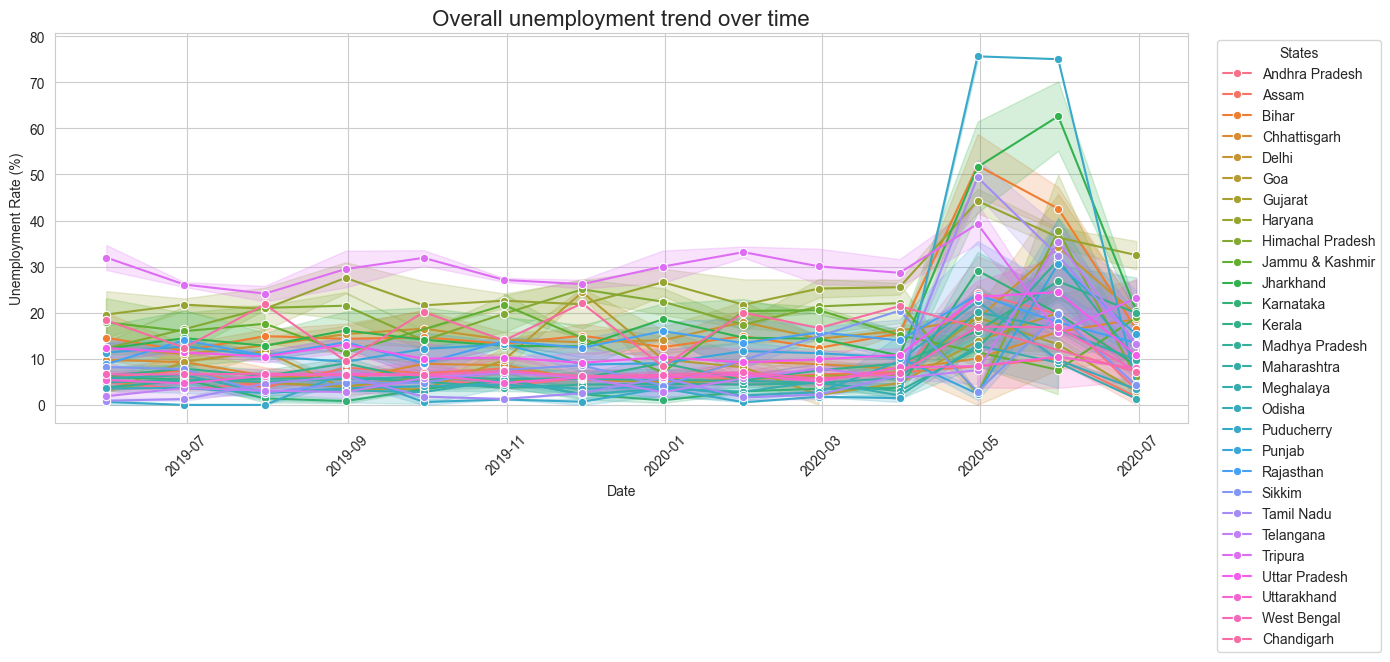

In [70]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data= df1,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    marker='o'
)

plt.title("Overall unemployment trend over time", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45, fontsize=10)

plt.legend(
    title='States',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

## Key Observations from the Graph

### 1. Massive Spike Around May–June 2020
- Unemployment rates suddenly increased sharply during this period.
- Several states recorded unemployment rates between **40%–70%**.

**Interpretation:**  
This spike corresponds to the nationwide **Covid-19 lockdown** in India, which caused major disruptions in employment and economic activities.

---

### 2. Most States Were Stable Before Covid-19
Before 2020:
- Most states maintained unemployment rates roughly between **2%–20%**.
- Fluctuations were comparatively smaller and more stable.

**Interpretation:**  
This indicates that unemployment trends were relatively stable during the pre-pandemic period.

---

### 3. Significant State-wise Variation
The graph shows noticeable differences among states:
- Some states consistently experienced higher unemployment rates.
- Certain states displayed stronger fluctuations and volatility over time.

**Interpretation:**  
Unemployment in India is highly region-dependent and influenced by local economic conditions, industries, and workforce structure.

---

### 4. Recovery After the Peak
After the sharp rise in unemployment:
- Several states began showing declining unemployment trends.
- The rates gradually moved toward more stable levels.

**Interpretation:**  
This suggests partial economic recovery after lockdown restrictions were eased and economic activities resumed.

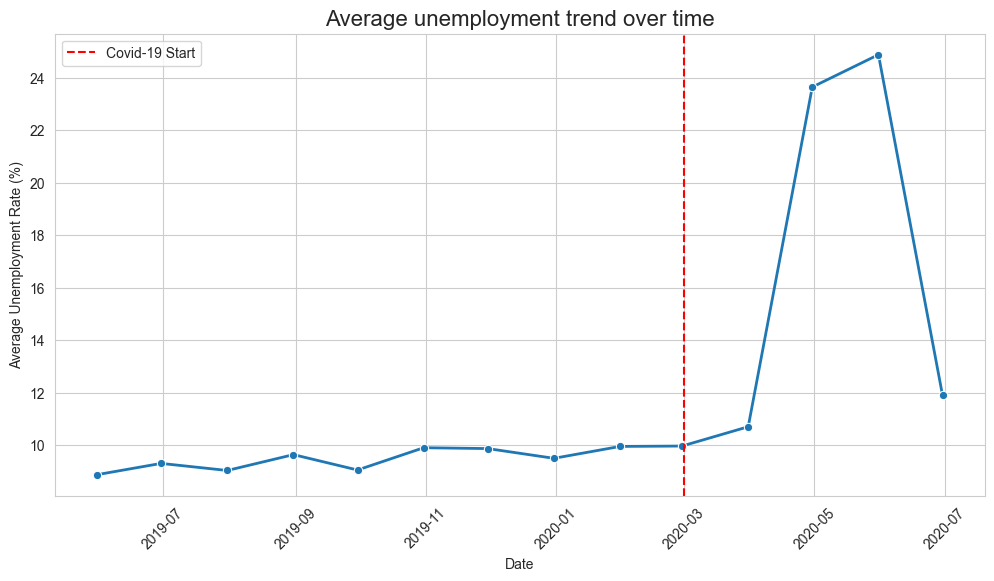

In [74]:
# plotting average monthly trend
# Combine all states for each month and calculate India’s average unemployment rate for that month.
avg_unemployment = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()


plt.figure(figsize=(12,6))
sns.lineplot(
    data = avg_unemployment,
    x = 'Date',
    y = 'Estimated Unemployment Rate (%)',
    marker = 'o',
    linewidth = 2
)

# covid-19 marker
plt.axvline(
    pd.to_datetime('2020-03-01'),
    color='red',
    linestyle='--',
    label='Covid-19 Start'
)

plt.title("Average unemployment trend over time", fontsize = 16)
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation = 45)

plt.legend()
plt.show()

### Observation

The average unemployment rate in India remained relatively stable before 2020, fluctuating between 8% and 10%. 

However, a sharp increase is observed during April–May 2020, where unemployment rates rose above 24%. This significant spike corresponds to the Covid-19 lockdown period, which caused major disruptions in economic activities and employment opportunities across the country.

A gradual decline is observed after the peak, indicating partial economic recovery after lockdown restrictions were eased.

# STATE-WISE UNEMPLOYMENT ANALYSIS

In [75]:
# average unemployment rate by region
state_avg_unemployment = (
    df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
)

In [76]:
# preview of top 5 states
state_avg_unemployment.head(5)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64

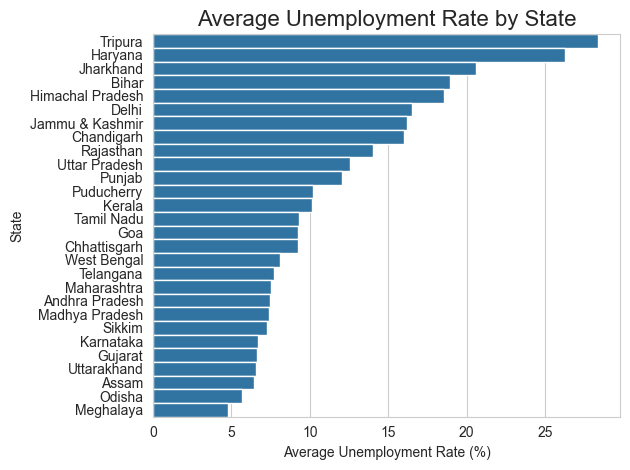

In [83]:
plt.Figure(figsize=(14,8))
sns.barplot(
    x = state_avg_unemployment.values,
    y = state_avg_unemployment.index,
    width = 1
)

plt.title("Average Unemployment Rate by State", fontsize = 16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State") 

plt.tight_layout()
plt.show()

### Observation

The analysis reveals significant regional variation in unemployment rates across India. 

Tripura, Haryana, and Jharkhand recorded the highest average unemployment rates, indicating greater employment challenges in these regions. 

In contrast, states such as Meghalaya and Odisha showed relatively lower unemployment rates. 

These differences suggest that unemployment in India is influenced by region-specific economic and social factors.

# AREA-WISE UNEMPLOYMENT ANALYSIS

In [84]:
df1['Area'].unique()

<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str

In [85]:
area_avg_unemployment = (
    df1.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
)

In [86]:
print(area_avg_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


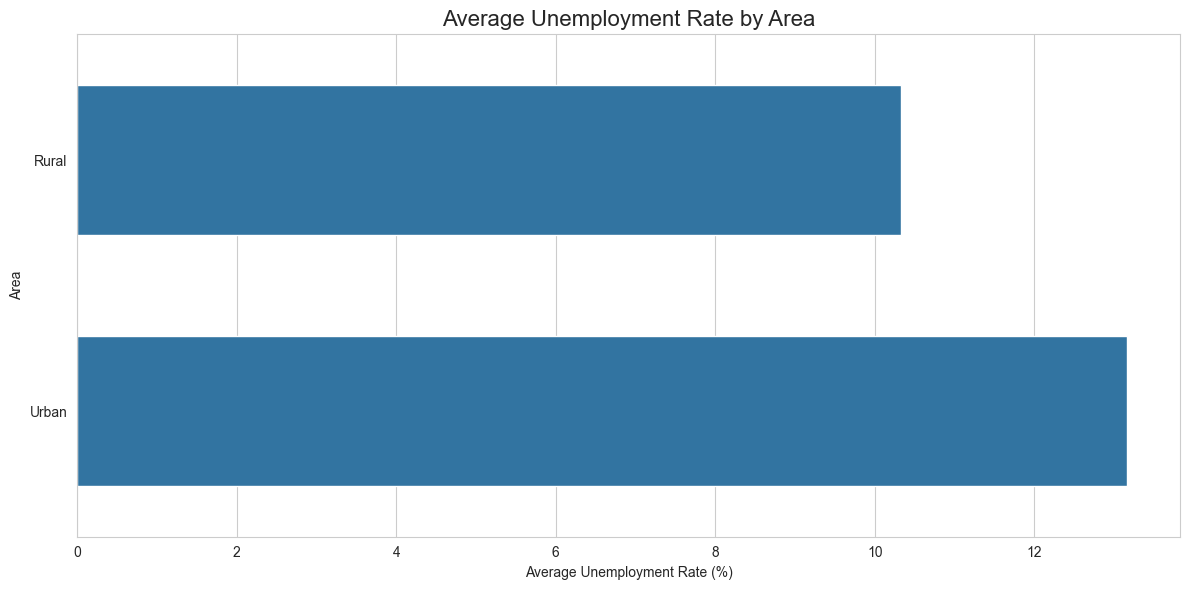

In [88]:
plt.figure(figsize=(12,6))
sns.barplot(
    x = area_avg_unemployment.values,
    y = area_avg_unemployment.index,
    width = 0.6
)

plt.title("Average Unemployment Rate by Area", fontsize = 16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Area")

plt.tight_layout()
plt.show()

### Observation

The analysis shows that urban areas consistently experienced higher unemployment rates compared to rural areas. 

This difference became more significant during the Covid-19 period, likely due to the shutdown of industries, offices, businesses, and service-sector jobs in urban regions.

Rural areas appeared comparatively more stable, possibly because of continued agricultural and local economic activities.

## Covid-19 Before vs After Analysis

In [89]:
before_covid = df1[df1['Date'] < '2020-03-01']

after_covid = df1[df1['Date'] >= '2020-03-01']

In [92]:
before_avg = before_covid['Estimated Unemployment Rate (%)'].mean()

after_avg = after_covid['Estimated Unemployment Rate (%)'].mean()

print(f'Before covid-19 average unemployment rate: {before_avg:.3f}%')
print(f'After covid-19 average unemployment rate: {after_avg:.3f}%')

Before covid-19 average unemployment rate: 9.510%
After covid-19 average unemployment rate: 17.774%


In [93]:
comparison_df = pd.DataFrame({
    'Period': ["Before Covid-19", "After Covid-19"],
    'Average Unemployment Rate (%)': [before_avg, after_avg]
})


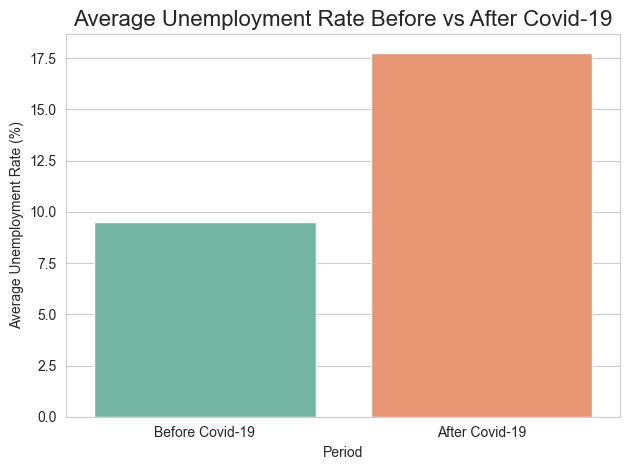

In [96]:
plt.Figure(figsize=(10,6))
sns.barplot(
    data = comparison_df,
    x = "Period",
    y = "Average Unemployment Rate (%)",
    palette = "Set2"
)

plt.title("Average Unemployment Rate Before vs After Covid-19", fontsize = 16)
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The average unemployment rate increased significantly after the Covid-19 outbreak. 

Before the pandemic, the average unemployment rate was approximately **9%**, and employment conditions remained relatively stable, indicating that although job availability challenges existed, people were still able to find employment opportunities with moderate difficulty.

However, after Covid-19 and the nationwide lockdown, the average unemployment rate increased sharply to nearly **18%**. This substantial rise reflects the severe impact of business closures, industrial shutdowns, reduced economic activity, and disruptions in the labor market during the pandemic period.

## Seasonal Trend Analysis

In [108]:
df1['Year_Month'] = df1['Date'].dt.strftime('%b-%Y')

In [115]:
month_order = (
    df1.sort_values('Date')['Year_Month'].unique()
)

monthly_trend = (
    df1.groupby('Year_Month')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
    )
monthly_trend['Year_Month'] = pd.Categorical(
    monthly_trend['Year_Month'],
    categories = month_order,
    ordered = True
    )

monthly_trend = monthly_trend.sort_values('Year_Month')


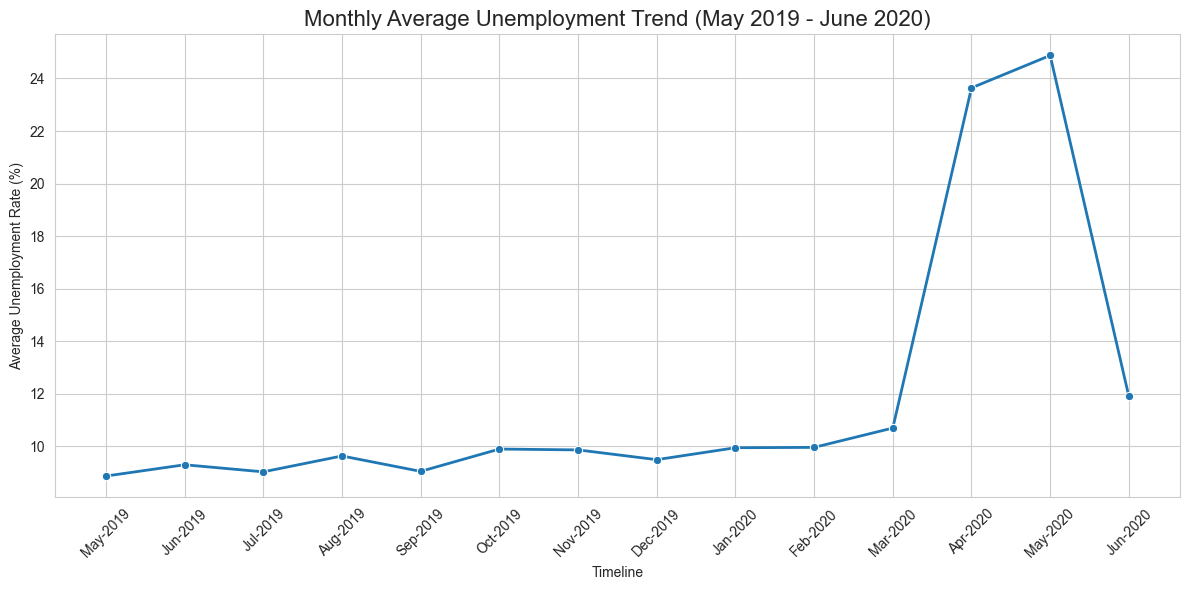

In [116]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data = monthly_trend,
    x = 'Year_Month',
    y = 'Estimated Unemployment Rate (%)',
    marker = 'o',
    linewidth = 2 
)

plt.title("Monthly Average Unemployment Trend (May 2019 - June 2020)", fontsize=16)

plt.xlabel("Timeline")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly unemployment trend remained relatively stable from May 2019 to early 2020, with unemployment rates generally staying below 10% for most months. Minor fluctuations were observed during this period, indicating moderate variations in employment conditions before the pandemic.

However, a dramatic increase in unemployment occurred during April and May 2020, where the unemployment rate sharply increased to nearly 24%–25%. This surge corresponds to the Covid-19 lockdown period, during which economic activities, industries, businesses, and labor-intensive jobs were severely affected.

A decline in unemployment is observed in June 2020, suggesting the beginning of economic recovery as lockdown restrictions started easing and employment activities gradually resumed.

## Correlation & Heatmap Analysis

In [117]:
correlation_data = df1[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

In [118]:
correlation_matrix = correlation_data.corr()
print(correlation_matrix)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


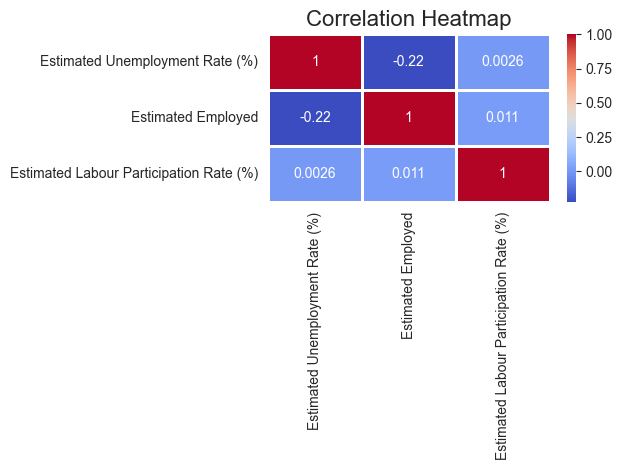

In [126]:
plt.Figure(figsize = (8,6))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    linewidths = 1
)

plt.title("Correlation Heatmap", fontsize = 16)

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows a weak negative relationship (-0.22) between unemployment rate and estimated employed population, indicating that unemployment tends to decrease slightly as employment increases.

However, the relationship is not very strong, suggesting that unemployment patterns are influenced by multiple economic and regional factors.

The labour participation rate shows almost no significant correlation with unemployment rate or employed population in this dataset.

# Key Insights

### 1. Stable Unemployment Before Covid-19

The unemployment rate remained relatively stable from mid-2019 to early 2020, generally staying below 10% for most months.

---

### 2. Major Impact of Covid-19 on Employment

A sharp rise in unemployment was observed during April and May 2020, where the average unemployment rate increased to nearly 24%–25%.

This significant increase reflects the economic disruption caused by the Covid-19 lockdown, including business closures, industrial shutdowns, and reduced economic activities.

---

### 3. Regional Variation in Unemployment

Significant differences in unemployment rates were observed across states.

States such as Tripura, Haryana, and Jharkhand recorded comparatively higher unemployment rates, indicating regional economic imbalance and varying employment opportunities.

---

### 4. Urban Areas Were More Affected

Urban areas experienced higher unemployment rates compared to rural areas.

This suggests that urban industries, businesses, and service-sector jobs were more severely affected during the pandemic period.

---

### 5. Gradual Recovery After Lockdown

A decline in unemployment was observed after the peak Covid period, indicating gradual economic recovery as restrictions eased and employment activities resumed.

---

### 6. Weak Correlation Between Variables

Correlation analysis showed a weak negative relationship between unemployment rate and employed population, while labour participation rate showed little significant correlation with other variables.

# Conclusion

The unemployment analysis reveals that India experienced relatively stable employment conditions before the Covid-19 pandemic. However, the nationwide lockdown in 2020 caused a sharp increase in unemployment rates due to disruptions in industries, businesses, and labor-intensive sectors.

The analysis also highlighted significant regional variation in unemployment across states and showed that urban areas were more severely affected compared to rural areas.

Although unemployment levels began declining after the lockdown period, the pandemic exposed the vulnerability of employment systems during large-scale economic disruptions.

This study demonstrates how data analysis and visualization techniques in Python can be used to understand economic trends, identify employment challenges, and support informed policy and planning decisions.